# Методы классификации: дерево решений

**Цель работы:** реализовать классификацию с помощью дерева решений в Python, проанализировать влияние способа разбиения исходного множества на обучающую и тестовую выборки, а также параметров модели на качество классификации.

**Исходные данные:** датасет **Breast Cancer Wisconsin (Diagnostic) Data Set**.  
Источник на Kaggle: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data


### 1. Импорт библиотек

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


### 2. Загрузка и первичный просмотр данных

In [2]:
possible_paths = [
    Path("breast_cancer_wisconsin_data.csv"),
    Path("wisconsin.csv"),
    Path("data.csv")
]

data_path = next((p for p in possible_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Не найден файл с данными. Положите рядом с ноутбуком "
        "'breast_cancer_wisconsin_data.csv'."
    )

df = pd.read_csv(data_path)
print(f"Используемый файл: {data_path.name}")
print(f"Размер набора данных: {df.shape[0]} строк и {df.shape[1]} столбцов")
df.head()


Используемый файл: breast_cancer_wisconsin_data.csv
Размер набора данных: 569 строк и 33 столбцов


,Unnamed: 0,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0,842302,M,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,1,842517,M,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,2,84300903,M,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,3,84348301,M,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,4,84358402,M,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               569 non-null    int64  
 1   id                       569 non-null    int64  
 2   diagnosis                569 non-null    str    
 3   radius_mean              569 non-null    float64
 4   texture_mean             569 non-null    float64
 5   perimeter_mean           569 non-null    float64
 6   area_mean                569 non-null    float64
 7   smoothness_mean          569 non-null    float64
 8   compactness_mean         569 non-null    float64
 9   concavity_mean           569 non-null    float64
 10  concave points_mean      569 non-null    float64
 11  symmetry_mean            569 non-null    float64
 12  fractal_dimension_mean   569 non-null    float64
 13  radius_se                569 non-null    float64
 14  texture_se               569 non-null

In [4]:
df.isna().sum().sort_values(ascending=False).head(10)


Unnamed: 0          0
id                  0
diagnosis           0
radius_mean         0
texture_mean        0
perimeter_mean      0
area_mean           0
smoothness_mean     0
compactness_mean    0
concavity_mean      0
dtype: int64

**Вывод.**  
Набор данных содержит достаточное количество наблюдений для выполнения лабораторной работы. Пропуски в используемых признаках отсутствуют, поэтому можно переходить к предобработке и построению модели.


### 3. Предобработка данных

In [5]:
work_df = df.copy()

# Удаляем технические поля, не несущие содержательной информации для классификации
work_df = work_df.drop(columns=["Unnamed: 0", "id"], errors="ignore")

# Кодируем целевую переменную:
# B -> 0 (доброкачественная опухоль), M -> 1 (злокачественная опухоль)
work_df["diagnosis_code"] = work_df["diagnosis"].map({"B": 0, "M": 1})

X = work_df.drop(columns=["diagnosis", "diagnosis_code"])
y = work_df["diagnosis_code"]

print("Размер матрицы признаков:", X.shape)
print("Распределение классов:")
print(y.value_counts().rename(index={0: "Benign", 1: "Malignant"}))


Размер матрицы признаков: (569, 30)
Распределение классов:
diagnosis_code
Benign       357
Malignant    212
Name: count, dtype: int64


**Вывод.**  
В качестве целевой переменной используется признак `diagnosis`. Для обучения дерева решений категориальные метки классов приведены к числовому виду: `0` — доброкачественная опухоль, `1` — злокачественная. Технические поля `id` и `Unnamed: 0` удалены, так как они не описывают свойства объекта и не должны влиять на классификацию.


### 4. Гипотезы исследования

**Гипотеза H0₁:** признаки набора данных не позволяют получить качественную классификацию диагнозов с помощью дерева решений.  
**Гипотеза H1₁:** признаки набора данных позволяют получить качественную классификацию диагнозов с помощью дерева решений.

**Гипотеза H0₂:** изменение доли обучающей и тестовой выборок, а также параметров дерева решений не влияет на качество классификации.  
**Гипотеза H1₂:** изменение доли обучающей и тестовой выборок, а также параметров дерева решений влияет на качество классификации.


### 5. Базовая модель дерева решений

В качестве базовой модели используем разбиение **80/20** и дерево решений с параметром `max_depth=3`.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

baseline_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_metrics = pd.DataFrame({
    "Метрика": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Значение": [
        accuracy_score(y_test, baseline_pred),
        precision_score(y_test, baseline_pred),
        recall_score(y_test, baseline_pred),
        f1_score(y_test, baseline_pred)
    ]
})

baseline_metrics


,Метрика,Значение
0,Accuracy,0.9035
1,Precision,0.9429
2,Recall,0.7857
3,F1-score,0.8571


In [7]:
print(classification_report(
    y_test,
    baseline_pred,
    target_names=["Benign", "Malignant"]
))


              precision    recall  f1-score   support

      Benign       0.89      0.97      0.93        72
   Malignant       0.94      0.79      0.86        42

    accuracy                           0.90       114
   macro avg       0.91      0.88      0.89       114
weighted avg       0.91      0.90      0.90       114



**Вывод.**  
Базовая модель показала хорошее качество классификации: общая точность превышает 0.90. При этом видно, что класс `Malignant` распознаётся немного хуже, чем класс `Benign`, поэтому далее целесообразно проверить, как изменится качество при изменении параметров дерева и способа разбиения выборки.


### 6. Анализ влияния способа разбиения выборки

Проверим гипотезу **H0₂ / H1₂** относительно того, влияет ли соотношение обучающей и тестовой выборок на качество классификации.  
Для чистоты сравнения оставим параметры дерева неизменными: `criterion='gini'`, `max_depth=3`.


In [8]:
split_results = []

for test_size in [0.20, 0.25, 0.30]:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=42
    )

    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=3,
        random_state=42
    )
    model.fit(X_train_s, y_train_s)
    pred_s = model.predict(X_test_s)

    split_results.append({
        "Разбиение train/test": f"{int((1 - test_size) * 100)}/{int(test_size * 100)}",
        "Accuracy": accuracy_score(y_test_s, pred_s),
        "Precision": precision_score(y_test_s, pred_s),
        "Recall": recall_score(y_test_s, pred_s),
        "F1-score": f1_score(y_test_s, pred_s)
    })

split_results_df = pd.DataFrame(split_results).sort_values(by="Accuracy", ascending=False)
split_results_df


,Разбиение train/test,Accuracy,Precision,Recall,F1-score
2,70/30,0.9181,1.0000,0.7812,0.8772
0,80/20,0.9035,0.9429,0.7857,0.8571
1,75/25,0.8881,0.9512,0.7358,0.8298


**Вывод.**  
Из таблицы видно, что изменение доли обучающей и тестовой выборок действительно влияет на итоговые метрики модели. Следовательно, гипотеза **H0₂** в части способа разбиения не подтверждается, а гипотеза **H1₂** принимается: качество классификации зависит от структуры разбиения данных.


### 7. Анализ влияния параметров дерева решений

Теперь проверим, как на качество классификации влияют глубина дерева и критерий разбиения узлов.  
Фиксируем разбиение **80/20**, а затем сравниваем разные значения `max_depth` и `criterion`.


In [9]:
param_results = []

for criterion in ["gini", "entropy"]:
    for depth in [2, 3, 4, 5, 6, None]:
        model = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=depth,
            random_state=42
        )
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        param_results.append({
            "criterion": criterion,
            "max_depth": "None" if depth is None else depth,
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred),
            "Recall": recall_score(y_test, pred),
            "F1-score": f1_score(y_test, pred)
        })

param_results_df = pd.DataFrame(param_results).sort_values(
    by=["Accuracy", "F1-score"],
    ascending=False
).reset_index(drop=True)

param_results_df


,criterion,max_depth,Accuracy,Precision,Recall,F1-score
0,entropy,5,0.9561,0.9744,0.9048,0.9383
1,entropy,None,0.9561,0.9744,0.9048,0.9383
2,entropy,3,0.9386,0.9268,0.9048,0.9157
3,gini,None,0.9298,0.9048,0.9048,0.9048
4,entropy,6,0.9298,0.9722,0.8333,0.8974
5,entropy,4,0.9298,1.0000,0.8095,0.8947
6,gini,6,0.9211,0.9231,0.8571,0.8889
7,gini,5,0.9211,0.9459,0.8333,0.8861
8,gini,2,0.9211,0.9714,0.8095,0.8831
9,gini,4,0.9123,0.9444,0.8095,0.8718


In [10]:
best_params_row = param_results_df.iloc[0]
best_params_row


criterion    entropy
max_depth          5
Accuracy      0.9561
Precision     0.9744
Recall        0.9048
F1-score      0.9383
Name: 0, dtype: object

**Вывод.**  
Сравнение параметров показывает, что качество классификации зависит от выбора глубины дерева и критерия разбиения. Наилучшие результаты показывает дерево с критерием `entropy` и глубиной `max_depth=5` (или полное дерево, если ориентироваться только на точность). Для дальнейшего анализа выберем модель `criterion='entropy'` и `max_depth=5`, так как она даёт высокое качество и при этом остаётся интерпретируемой.


### 8. Итоговая модель

In [11]:
final_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

final_model.fit(X_train, y_train)
final_pred = final_model.predict(X_test)

final_metrics = pd.DataFrame({
    "Метрика": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Значение": [
        accuracy_score(y_test, final_pred),
        precision_score(y_test, final_pred),
        recall_score(y_test, final_pred),
        f1_score(y_test, final_pred)
    ]
})

final_metrics


,Метрика,Значение
0,Accuracy,0.9561
1,Precision,0.9744
2,Recall,0.9048
3,F1-score,0.9383


In [12]:
print(classification_report(
    y_test,
    final_pred,
    target_names=["Benign", "Malignant"]
))


              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



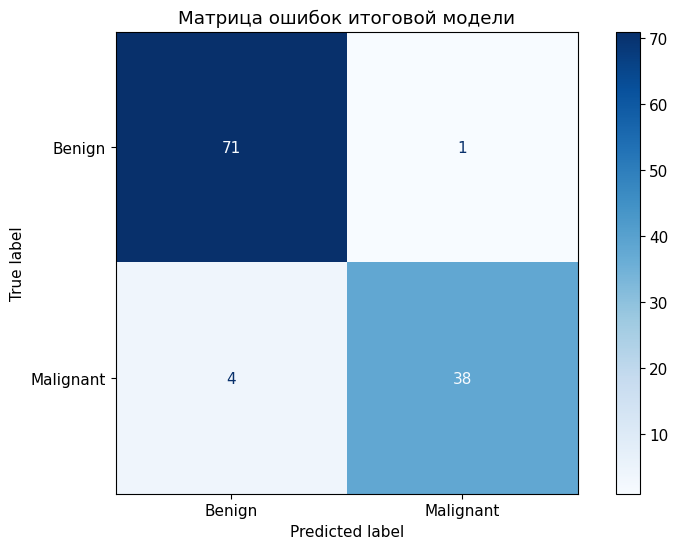

In [13]:
cm = confusion_matrix(y_test, final_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)
disp.plot(cmap="Blues")
plt.title("Матрица ошибок итоговой модели")
plt.grid(False)
plt.show()


**Вывод.**  
Итоговая модель улучшила качество классификации по сравнению с базовой. Особенно важно, что выросло качество распознавания класса `Malignant`, то есть модель стала лучше обнаруживать злокачественные опухоли.


### 9. Кросс-валидация итоговой модели

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(final_model, X, y, cv=cv, scoring="accuracy")

print("Оценки accuracy по фолдам:", np.round(cv_scores, 4))
print("Средняя accuracy:", round(cv_scores.mean(), 4))
print("Стандартное отклонение:", round(cv_scores.std(), 4))


Оценки accuracy по фолдам: [0.9298 0.9123 0.9737 0.9474 0.9292]
Средняя accuracy: 0.9385
Стандартное отклонение: 0.0208


**Вывод.**  
Результаты кросс-валидации подтверждают устойчивость итоговой модели: значения accuracy по фолдам близки друг к другу, а стандартное отклонение невелико. Это означает, что полученное качество не является случайным для одного конкретного разбиения.


### 10. Значимость признаков

In [15]:
feature_importance = (
    pd.Series(final_model.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
)

feature_importance.head(10)


perimeter_worst        0.6305
concave points_worst   0.1075
concave points_mean    0.0811
texture_worst          0.0675
area_se                0.0464
radius_worst           0.0196
compactness_se         0.0163
texture_mean           0.0125
area_worst             0.0094
concavity_mean         0.0092
dtype: float64

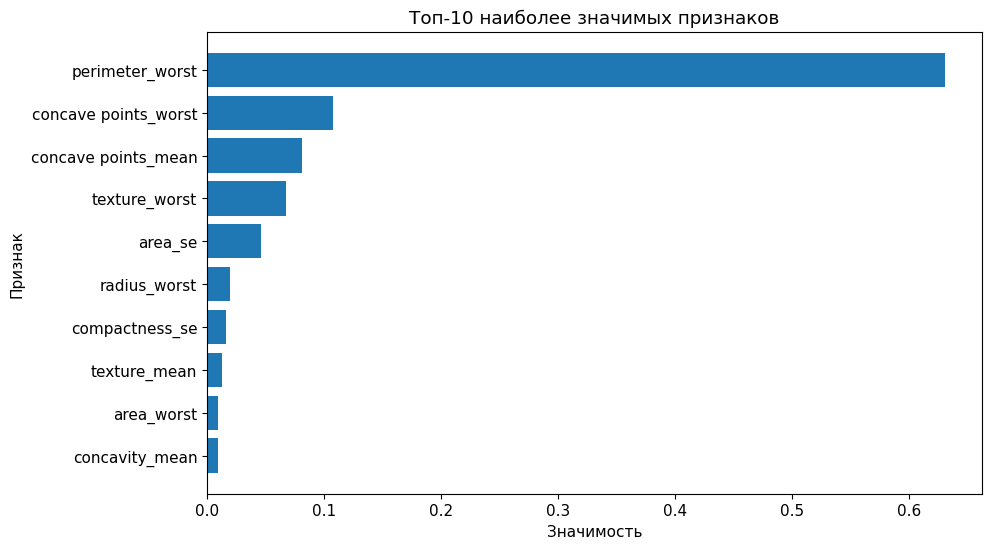

In [16]:
top_features = feature_importance.head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top_features.index, top_features.values)
plt.title("Топ-10 наиболее значимых признаков")
plt.xlabel("Значимость")
plt.ylabel("Признак")
plt.show()


**Вывод.**  
Наибольший вклад в классификацию вносят признаки, связанные с размером и формой новообразования. Это означает, что дерево решений в первую очередь использует наиболее информативные морфологические характеристики, а менее значимые признаки практически не влияют на финальное решение модели.


### 11. Графическое представление дерева решений

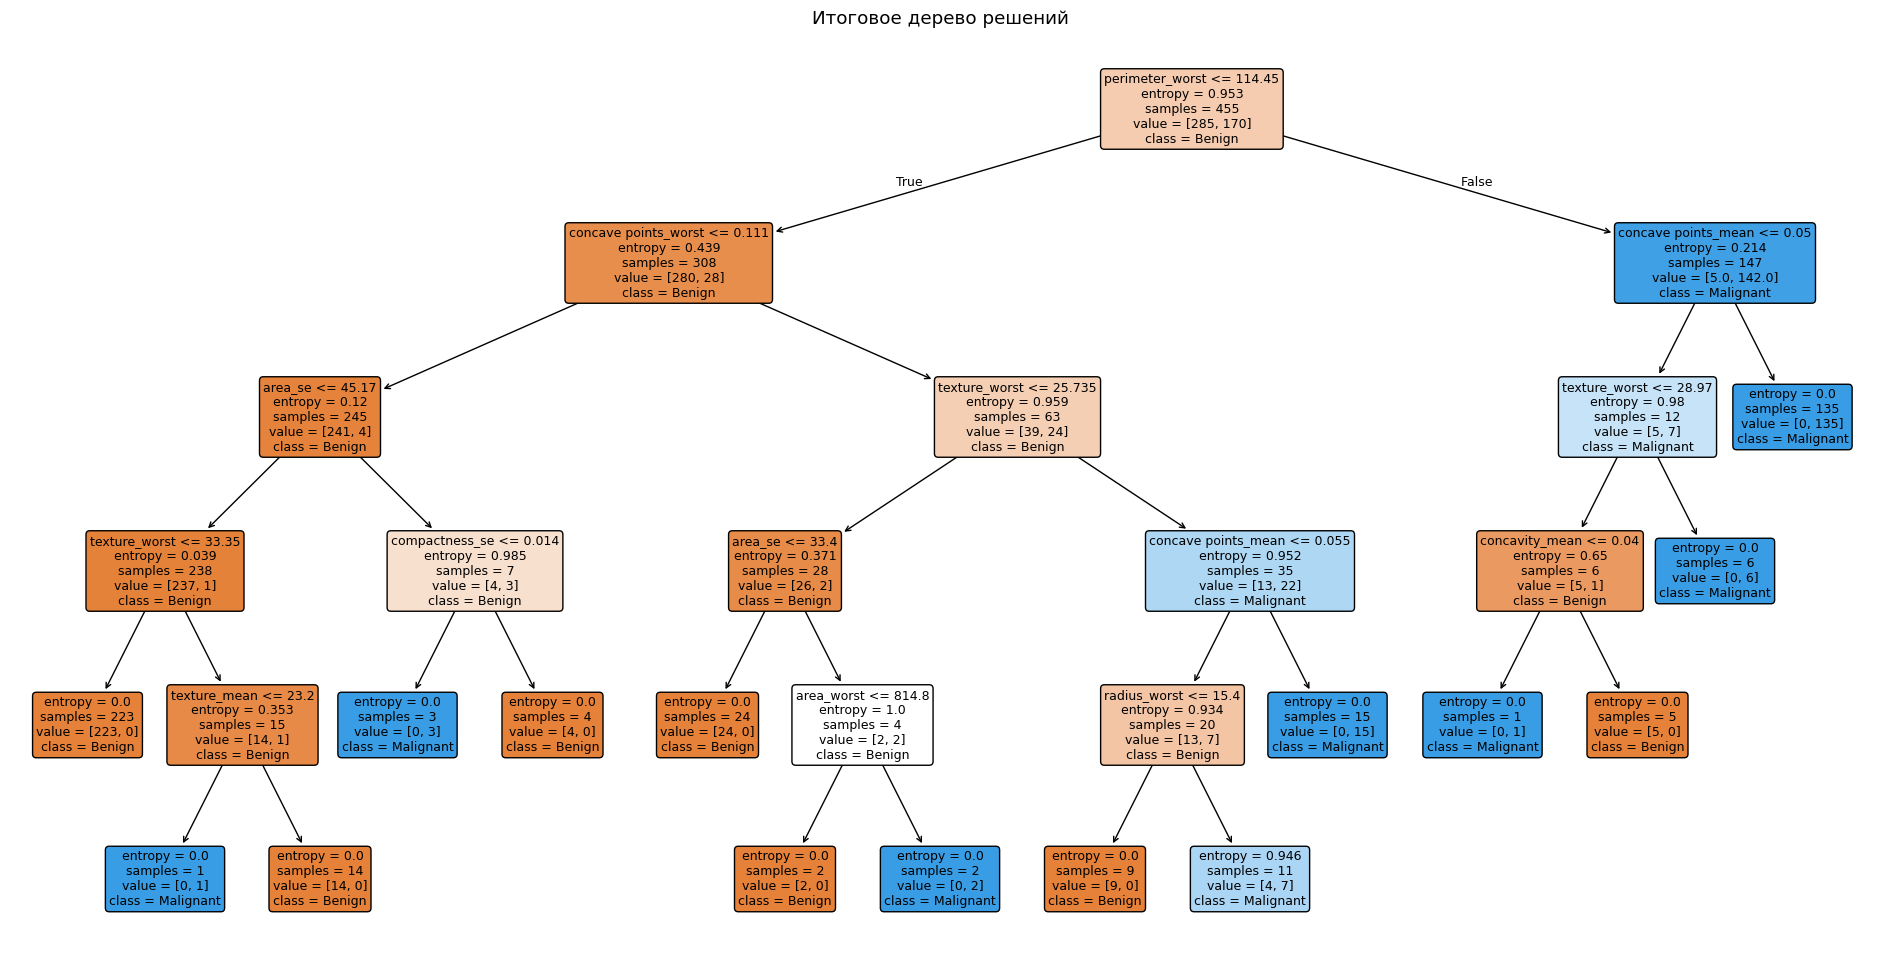

In [17]:
plt.figure(figsize=(24, 12))
plot_tree(
    final_model,
    feature_names=X.columns,
    class_names=["Benign", "Malignant"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Итоговое дерево решений")
plt.show()


**Вывод.**  
По дереву решений можно увидеть, какие именно признаки используются на верхних уровнях модели и, следовательно, сильнее всего влияют на итоговую классификацию. Узлы верхнего уровня содержат наиболее информативные условия разделения объектов на классы.


## Вывод по работе

В ходе работы была реализована классификация с помощью дерева решений для диагностики опухолей молочной железы.  
Базовая модель с параметрами `max_depth=3` и `criterion='gini'` показала хорошее качество, однако дополнительный анализ позволил улучшить результат.

Проверка гипотез показала следующее:

- гипотеза **H1₁** подтверждается: признаки датасета действительно позволяют построить качественную модель классификации;
- гипотеза **H1₂** также подтверждается: изменение разбиения выборки и параметров дерева влияет на метрики качества.

Наилучший компромисс между качеством и интерпретируемостью показала модель с параметрами `criterion='entropy'` и `max_depth=5`.  
Итоговая модель демонстрирует высокую точность классификации, устойчивость по результатам кросс-валидации и позволяет интерпретировать наиболее важные признаки, влияющие на диагноз.
